<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
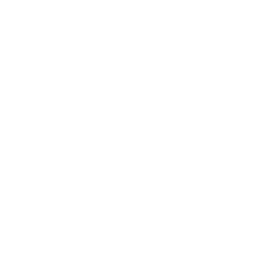
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnose af kemisk reaktorforstyrrelse</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identificér variable, der driver reaktorens T2-overskridelse under en forstyrrelse &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

En kontinuert omrørt tankreaktor (CSTR) drev ind i en termisk
forstyrrelse, da dens kølemiddelforsyning forringedes. Under normal
drift bevæger kølemiddelflow, reaktortemperatur og kappetemperatur sig
sammen langs én proceslast-akse. Vi opbygger en tre-komponent MVP-model
på 100 observationer fra normal drift og scorer derefter 100
forstyrrelsesobservationer mod den med `PROC MVPDIAGNOSE`. Ved at
dekomponere Hotellings *T*-kvadreret-statistik i per-variabel-bidrag
isoleres den termisk koblede trio — `jacket_temp`, `coolant_flow` og
`reactor_temp` — som de variable, der driver overskridelsen, og peger
driften direkte mod kølemiddelundersystemet.

## Datakilder

| Datasæt | Rolle | Observationer |
|---|---|---|
| `reactor_normal` | Træningsdata fra normal drift til MVP-modellen | 100 |
| `reactor_upset` | Forstyrrelsesobservationer scoret mod modellen | 100 |

De seks målte variable er `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L), og `pressure` (bar).
Begge datasæt er simuleret ud fra en fælles latent *proceslast*, så
normaldataene bærer den samme korrelationsstruktur, som en reel CSTR
udviser; forstyrrelsen indfører et kølemiddeltab, der bryder denne
struktur.

## Trin 1 — Træn MVP-modellen for normal drift

Normal drift styres af en latent proceslast: højere last trækker
kølemiddelflowet ned, mens den skubber reaktor- og kappetemperaturerne
op. `PROC MVPMODEL` udtrækker tre principale komponenter fra de 100
normalobservationer og gemmer dem med `OUTMODEL=`, så
diagnosetrinnet kan score nye data mod den samme reference.

In [1]:
data reactor_normal;
  CALL streaminit(7);
  GØR t = 1 TIL 100;
    load = rand('normal', 0, 1);                 /* latent proceslast */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    UDDATA;
  SLUT;
KØR;

PROC MVPMODEL data=reactor_normal outmodel=reactor_model;
  VARIABEL reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
KØR;


                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Trin 2 — Scor forstyrrelseshændelsen og dekomponér *T*-kvadreret

Forstyrrelsen reducerer kølemiddelflowet med omtrent 12 L/min, mens
reaktor- og kappetemperaturerne stiger — den normale
kølemiddel/temperatur-kobling er brudt. `PROC MVPDIAGNOSE` scorer hver
forstyrrelsesobservation mod referencemodellen, skriver de
standardiserede scorer og residualer til `OUT=` og
per-variabel-*T*-kvadreret-bidragene til `OUTCONTRIB=`. Hver
observation lander langt uden for kontrolgrænsen, hvilket bekræfter en
vedvarende multivariat afvigelse frem for isoleret støj.

In [2]:
data reactor_upset;
  CALL streaminit(101);
  GØR t = 1 TIL 100;
    load = rand('normal', 0, 1);
    /* Kølemiddelpumpen forringes: flowet falder, temperaturerne løber løbsk */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    UDDATA;
  SLUT;
KØR;

PROC MVPDIAGNOSE data=reactor_upset model=reactor_model
                 out=reactor_scores;
  VARIABEL reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
KØR;


                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Trin 3 — Ranger de gennemsnitlige bidrag

`OUTCONTRIB=` skriver én række pr. scoret observation med en
`<variable>_CONTRIB`-kolonne for hver procesvariabel. Ved at beregne
gennemsnittet af disse kolonner fås hver variabels gennemsnitlige bidrag
til forstyrrelsen; en transponering omformer det ét-rækkes resumé til en
overskuelig variabel/værdi-tabel, der rangerer fejlkilderne.

In [3]:
PROC MEANS data=reactor_contrib mean NOPRINT;
  VARIABEL reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  UDDATA out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
KØR;

PROC TRANSPOSE data=contrib_means out=contrib_long name=metric;
  VARIABEL mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
KØR;

/* Tilføj læsbare variabelnavne og den gennemsnitlige bidragsværdi */
data contrib_ranked;
  SÆT contrib_long;
  LÆNGDE variable $14;
  HVIS      metric = 'mc_reactor_temp' SÅ variable = 'reactor_temp';
  ELLERS HVIS metric = 'mc_coolant_flow' SÅ variable = 'coolant_flow';
  ELLERS HVIS metric = 'mc_jacket_temp'  SÅ variable = 'jacket_temp';
  ELLERS HVIS metric = 'mc_feed_conc'    SÅ variable = 'feed_conc';
  ELLERS HVIS metric = 'mc_pressure'     SÅ variable = 'pressure';
  mean_contrib = col1;
  BEHOLD variable mean_contrib;
KØR;

PROC SORT data=contrib_ranked;
  EFTER FALDENDE mean_contrib;
KØR;

PROC PRINT data=contrib_ranked noobs MÆRKAT;
  VARIABEL variable mean_contrib;
  MÆRKAT variable='Procesvariabel' mean_contrib='Gennemsnitligt T-kvadreret-bidrag';
KØR;


Procesvariabel  Gennemsnitligt T-kvadreret-bidrag
--------------  ---------------------------------
jacket_temp                         4177.66720283
coolant_flow                        2882.19501987
reactor_temp                        1602.04200377
pressure                             280.73140863
feed_conc                             61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/55dd3a7a-5e93-423b-a95e-e8c2071ca46c/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Trin 4 — Bidragsplot

Bidragsplottet gør diagnosen umiddelbar: den termisk koblede trio —
`jacket_temp`, `coolant_flow` og `reactor_temp` — overgår langt
`feed_conc` og `pressure`, som knap nok registrerer. De tre dominerende
søjler er præcis de variable, der er koblet sammen af kølemiddelkredsen,
så fejlen er utvetydigt termisk og ikke et foder- eller trykproblem.


NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


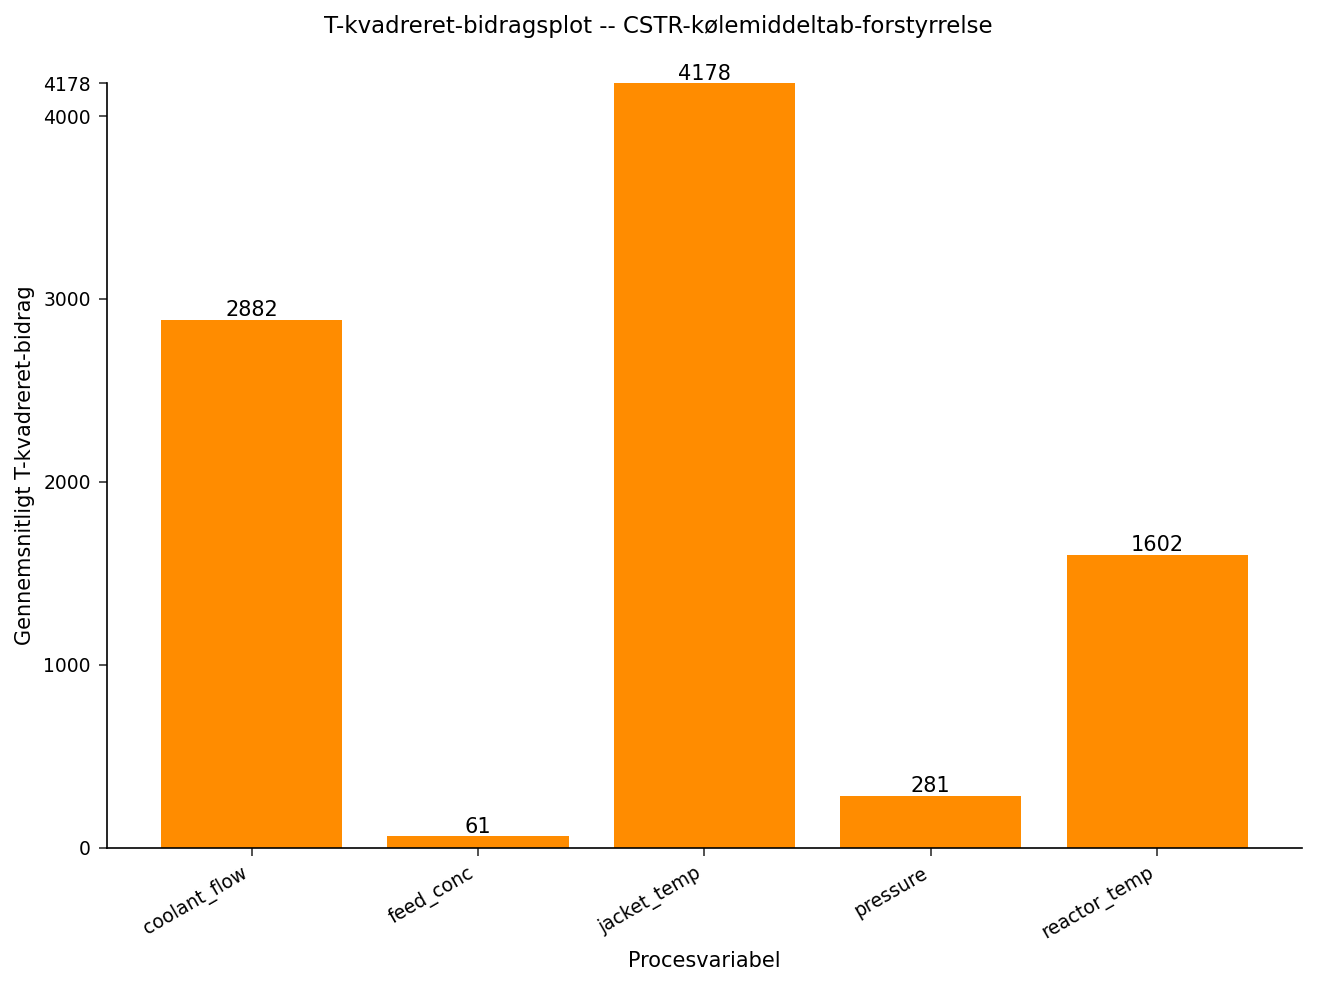

In [4]:
PROC SGPLOT data=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS MÆRKAT='Procesvariabel';
  YAXIS MÆRKAT='Gennemsnitligt T-kvadreret-bidrag';
  TITEL 'T-kvadreret-bidragsplot -- CSTR-kølemiddeltab-forstyrrelse';
KØR;

## Trin 5 — *T*-kvadreret-kontroltidslinje

At plotte hver observations *T*-kvadreret mod modellens kontrolgrænse
viser, at afvigelsen er vedvarende: hver forstyrrelsesobservation ligger
størrelsesordener over grænsereferencelinjen. Der er ingen genopretning
inden for vinduet, i overensstemmelse med en hardwarefejl, der
fortsætter, indtil kølemiddelundersystemet efterses.


NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


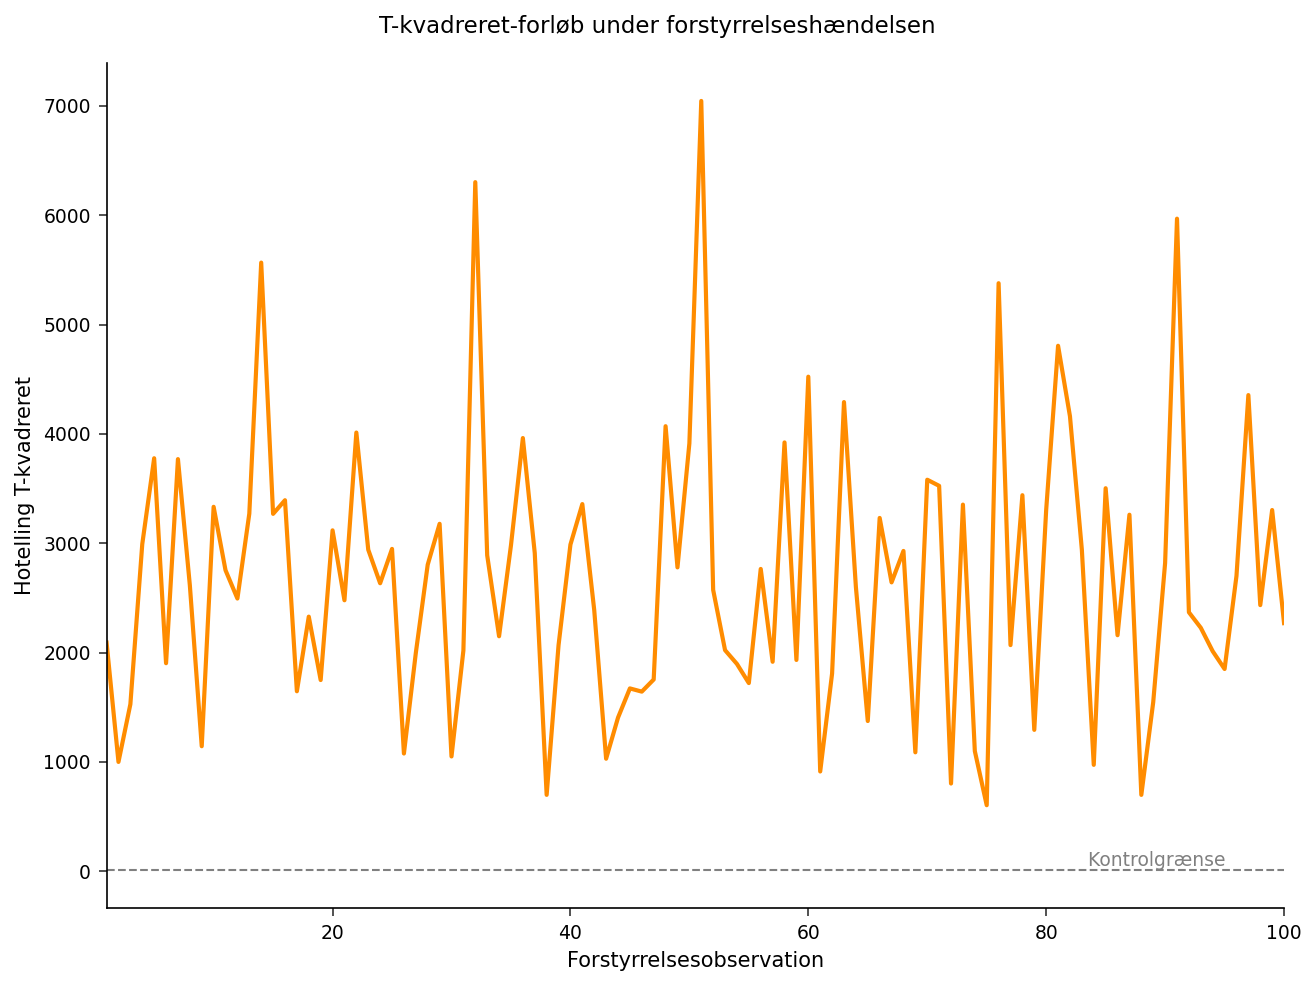

In [5]:
PROC SGPLOT data=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  MÆRKAT='Kontrolgrænse'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS MÆRKAT='Forstyrrelsesobservation';
  YAXIS MÆRKAT='Hotelling T-kvadreret';
  TITEL 'T-kvadreret-forløb under forstyrrelseshændelsen';
KØR;

## Resultater &amp; korrigerende handling

- **Vigtigste drivere**: `jacket_temp`, `coolant_flow` og `reactor_temp`
  tegner sig samlet for stort set hele *T*-kvadreret-signalet; deres
  gennemsnitlige bidrag er to til tre størrelsesordener over
  `feed_conc` og `pressure`.
- **Grundårsag**: et tab af kølemiddelforsyning. `coolant_flow` er den
  eneste *manipulerede* variabel af de tre — temperaturstigningerne er
  nedstrøms konsekvenser af tabt køling, så den handlingsrettede fejl
  er kølemiddelundersystemet.
- **Kontrolstatus**: alle 100 forstyrrelsesobservationer overskrider
  *T*-kvadreret-grænsen, hvilket indikerer en vedvarende afvigelse
  frem for en forbigående hændelse.
- **Korrigerende handling**: efterse og genopbyg kølemiddelpumpen; tilføj
  en redundant kølemiddelflow-transmitter, så et fremtidigt
  forsyningstab fanges af univariat alarmering, før det spreder sig til
  temperaturkredsen.

## Eksportér de rangerede bidrag

Den rangerede bidragstabel skrives til CSV til brug i
efterhændelsesrapporten og downstream-dashboards.

In [6]:
PROC EXPORT data=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>